# Grand-Tours-Analysis (GTA) group
## Exploratory data analysis


In [1]:
import pandas as pd
import numpy as np
import sqlite3
import seaborn as sns
import re
# plotting
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib import style
plt.style.use('bmh')
#
# import os
# import pathlib
# file = pathlib.Path(__file__).parent.resolve()

In [2]:
db_path = "data/grand_tours.db"
# db_path = "data/training.db"

Summary using sqlite3 Database

In [3]:
def basic_database_summary(db_path):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    #
    newline_indent = '\n   '
    conn.text_factory = str
    #
    result = cursor.execute("SELECT name FROM sqlite_master WHERE type='table';").fetchall()
    table_names = sorted(list(zip(*result))[0])
    print ("\ntables are:"+newline_indent+newline_indent.join(table_names))
    #
    for table_name in table_names:
        result = cursor.execute("PRAGMA table_info('%s')" % table_name).fetchall()
        column_names = list(zip(*result))[1]
        print (("\n\nColumn schema for table %s:" % table_name))
        for row in cursor.execute("PRAGMA table_info('%s')" % table_name).fetchall():
            print(row)
    #
    cursor.close()
    conn.close()

In [4]:
basic_database_summary(db_path)


tables are:
   giro_results
   segments_data
   stats_data
   strava_names
   strava_table
   tdf_results
   vuelta_results


Column schema for table giro_results:
(0, 'year', 'INTEGER', 0, None, 0)
(1, 'stage', 'TEXT', 0, None, 0)
(2, 'name', 'TEXT', 0, None, 0)
(3, 'time', 'TEXT', 0, None, 0)
(4, 'date', 'TEXT', 0, None, 0)
(5, 'start_time', 'TEXT', 0, None, 0)
(6, 'winner_avg_speed', 'REAL', 0, None, 0)
(7, 'distance', 'REAL', 0, None, 0)
(8, 'profile_score', 'REAL', 0, None, 0)
(9, 'vertical_meters', 'REAL', 0, None, 0)
(10, 'Departure:', 'TEXT', 0, None, 0)
(11, 'Arrival:', 'TEXT', 0, None, 0)
(12, 'startlist_quality', 'INTEGER', 0, None, 0)
(13, 'won_how', 'TEXT', 0, None, 0)
(14, 'avg_temperature', 'REAL', 0, None, 0)
(15, 'stage_number', 'TEXT', 0, None, 0)
(16, 'stage_num', 'INTEGER', 0, None, 0)
(17, 'ITT', 'INTEGER', 0, None, 0)


Column schema for table segments_data:
(0, 'activity_id', 'INTEGER', 0, None, 0)
(1, 'athlete_id', 'INTEGER', 0, None, 0)
(2, 'date', 'TEXT', 0, 

In [5]:
def get_max_stage_from_year(db_path, table_name, year_num):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    #
    cursor.execute(f"""SELECT stage FROM "{table_name}" WHERE year = "{year_num}" """)
    rows = cursor.fetchall()
    # Extract stage numbers and count frequencies
    stage_counts = {}
    for row in rows:
        stage_text = row[0]
        match = re.search(r'\d+', stage_text)
        if match:
            stage_number = int(match.group()) if match else None
            stage_counts[stage_number] = stage_counts.get(stage_number, 0) + 1
    #
    conn.close()
    return max(stage_counts) 

In [6]:
def get_yearly_summary_of_tours(db_path, table_name):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    #
    if table_name == "tdf_results":
        tour_name = "tdf"
    elif table_name == "giro_results":
        tour_name = "giro"
    elif table_name == "vuelta_results":
        tour_name = "vuelta"
    else:
        raise ValueError("Invalid table name.")
    #
    # Create a {tour:color} dictionary/map 
    tour_colors = {'tdf': 'yellow','giro': 'pink', 'vuelta': 'red'}
    #
    # Retrieve unique years and their counts
    cursor.execute(f"""SELECT year, COUNT(*) FROM "{table_name}" GROUP BY year""")
    rows = cursor.fetchall()
    #
    years = []
    freqs = []
    max_stages =[]
    for year, freq in rows:
        max_stage = get_max_stage_from_year(db_path, table_name, year)  
        #
        if max_stage is not None:
            years.append(year)
            freqs.append(freq)
            max_stages.append(max_stage)
    #
    #-----------------------------------#
    # Create histogram
    fig, ax1 = plt.subplots(figsize=(12,4))
    #
    ax1.bar(years, freqs, color=tour_colors[tour_name], alpha=0.6, label='Frequency', ec='k', lw=0.5)
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Frequency (no. of rows)', color='b')
    ax1.tick_params(axis='y', labelcolor='b')
    xvalues = np.linspace(1910,2030,13, dtype=int)
    plt.xticks(xvalues, [str(x) for x in xvalues], rotation=0) 
    # 
    ax2 = ax1.twinx()
    ax2.plot(years,max_stages, color='r', marker='.', linestyle='-', label='Max Stage')
    ax2.set_ylabel('Number of Stages', color='r', fontsize=10)
    ax2.tick_params(axis='y', labelcolor='r')
    ax2.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax2.set_ylim(ymin=0)
    # 
    plt.title( tour_name + " yearly summary of data", fontsize=10)
    # plt.savefig("Plots/"+tour_name + "_"+ "data_yearly_summary.png", bbox_inches='tight')
    fig.tight_layout()
    plt.show()
    #-----------------------------------#
    #
    cursor.close()
    conn.close()
    return None
    #return years,freqs,max_stages

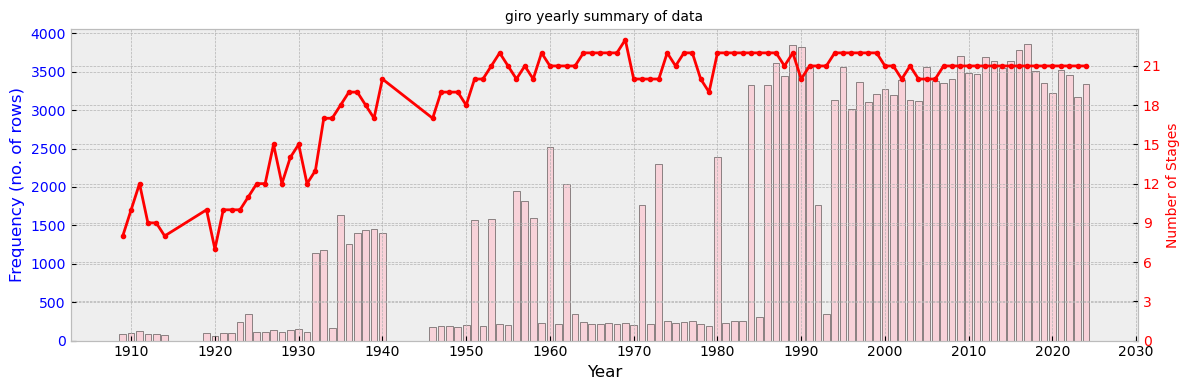

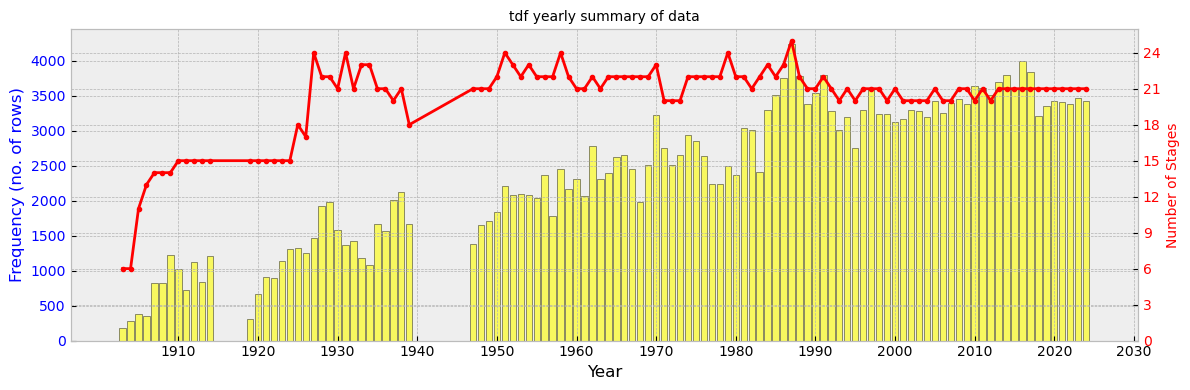

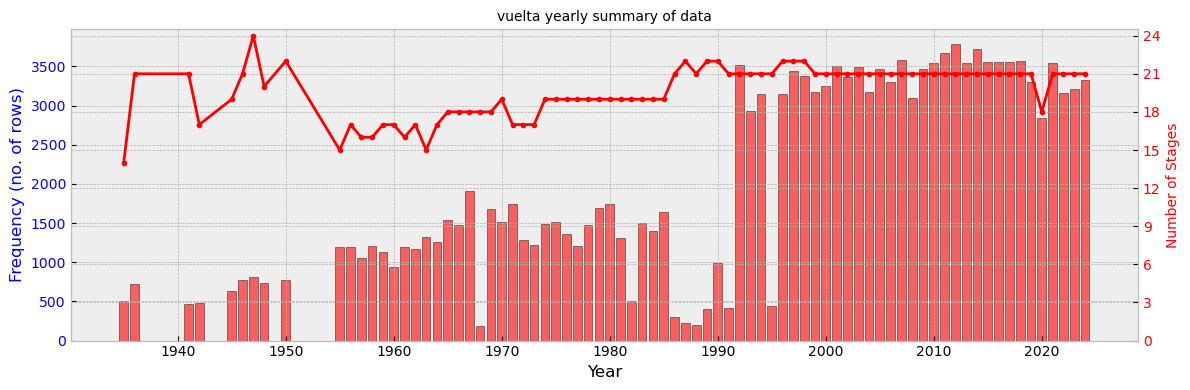

In [7]:
## yearly summary of one of the three tours
get_yearly_summary_of_tours(db_path, "giro_results")
get_yearly_summary_of_tours(db_path, "tdf_results")
get_yearly_summary_of_tours(db_path, "vuelta_results")

In [8]:
def get_summary_of_specific_tour_year(db_path, table_name, year_num):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    #
    if table_name == "tdf_results":
        tour_name = "tdf"
    elif table_name == "giro_results":
        tour_name = "giro"
    elif table_name == "vuelta_results":
        tour_name = "vuelta"
    else:
        raise ValueError("Invalid table name.")
    #
    # Create a {tour:color} dictionary/map 
    tour_colors = {'tdf': 'yellow','giro': 'pink', 'vuelta': 'red'}
    #
    cursor.execute(f"""SELECT stage FROM "{table_name}" WHERE year = "{year_num}" """)
    rows = cursor.fetchall()
    # get stage numbers and their frequencies
    stage_counts = {}
    for row in rows:
        stage_text = row[0]
        match = re.search(r'\d+', stage_text)
        if match:
            stage_number = int(match.group())
            stage_counts[stage_number] = stage_counts.get(stage_number, 0) + 1
    #
    stages = []
    rider_freqs = []
    for stage, freq in sorted(stage_counts.items()):
        if rider_freqs is not None:
            stages.append(stage)
            rider_freqs.append(freq)
    #
    #-----------------------------------#
    fig, ax1 = plt.subplots(figsize=(7,3))
    #
    ax1.bar(stages, rider_freqs, color=tour_colors[tour_name], alpha=1.0, label="GRO-"+ str(year_num), ec='k', lw=0.5)
    ax1.set_xlabel('Stage')
    ax1.set_ylabel('No. of riders', color='b')
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax1.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    xvalues = np.linspace(1,max(stage_counts), dtype=int)
    plt.xticks(xvalues, [str(x) for x in xvalues]) 
    #
    plt.title(tour_name + "-"+ str(year_num),fontsize=12)
    plt.savefig("Plots/" + tour_name + "_"+ str(year_num) + "_summary.png", bbox_inches='tight')
    fig.tight_layout()
    plt.show()
    #-----------------------------------#
    # 
    cursor.close()
    conn.close()

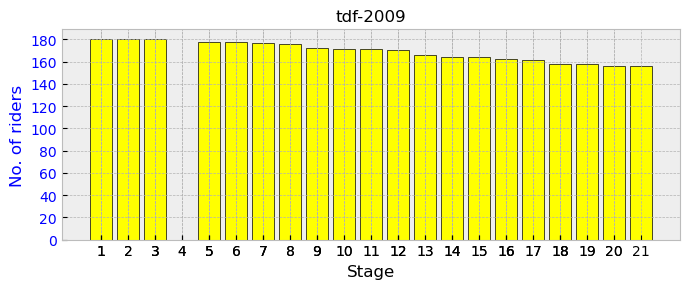

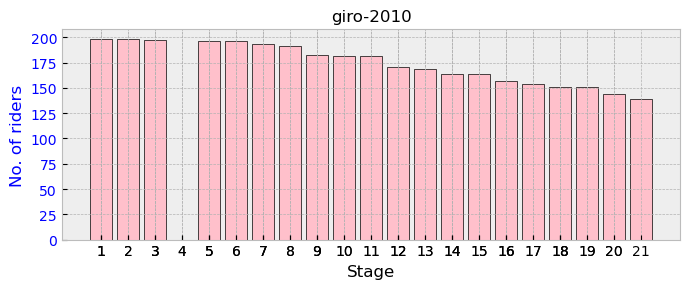

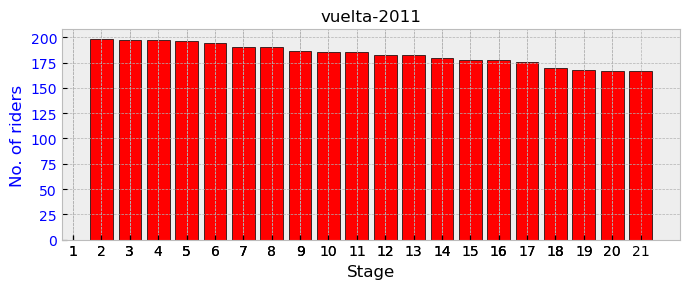

In [9]:
get_summary_of_specific_tour_year(db_path, "tdf_results",2009)
get_summary_of_specific_tour_year(db_path, "giro_results",2010)
get_summary_of_specific_tour_year(db_path, "vuelta_results",2011)

In [10]:
def get_summary_of_starava_data(db_path, table_name):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    #
    cursor.execute(f"""SELECT year, COUNT(*) FROM "{table_name}" GROUP BY year""")
    rows = cursor.fetchall()
    #
    years = []
    freqs = []
    for year, freq in rows:
        years.append(year)
        freqs.append(freq)
    #
    #-----------------------------------#
    # Create histogram
    fig, ax = plt.subplots(figsize=(9,4))
    ax.bar(years, freqs, color='b', alpha=0.8, label='tour', ec='k', lw=0.5)
    ax.set_xlabel('Year')
    ax.set_ylabel('Frequency (no. of rows)', color='b')
    plt.title( table_name + " frequency plot by year", fontsize=12)
    xvalues = np.linspace(2013,2025,11, dtype=int)
    plt.xticks(xvalues, [str(x) for x in xvalues], rotation=0) 
    # plt.savefig("Plots/"+table_name + "_"+ "frequency_plot_by_year.png", bbox_inches='tight')
    fig.tight_layout()
    plt.show()
    #-----------------------------------#
    cursor.close()
    conn.close()
    return None

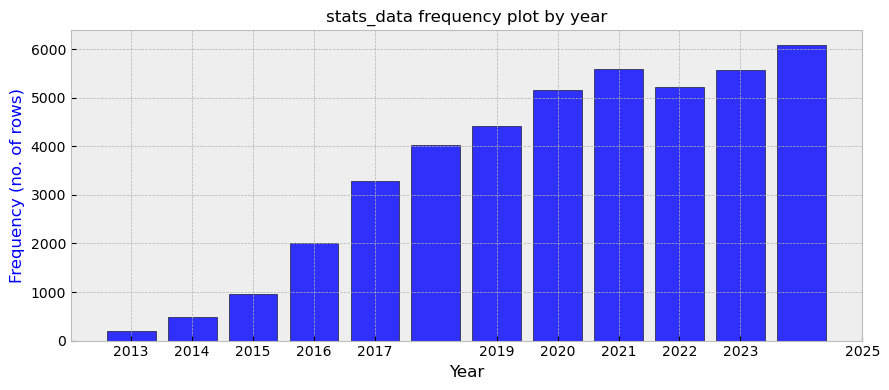

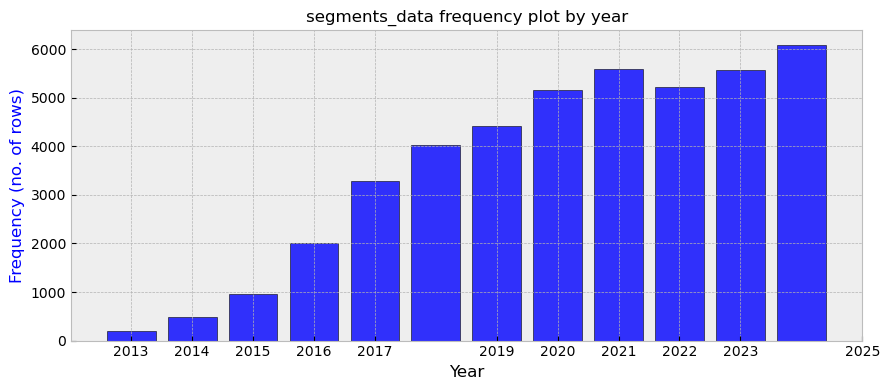

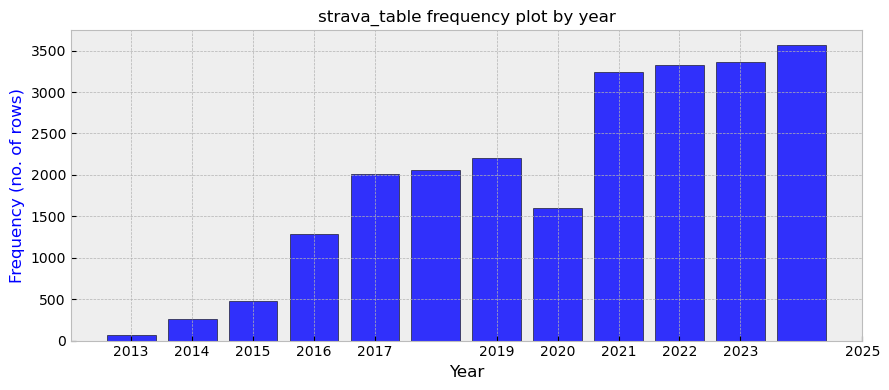

In [11]:
get_summary_of_starava_data(db_path, "stats_data")
get_summary_of_starava_data(db_path, "segments_data")
get_summary_of_starava_data(db_path, "strava_table")

# Database summary using pandas

I have separated the <code>tour_year </code> column in the tables <code>segments_data</code>, <code>stats_data</code>, <code>strava_table</code> into 'tour' and 'year' columns using 'Split_tour_year.py'

In [12]:
db_path = "data/grand_tours.db"
# db_path ="data/training.db"

In [13]:
conn = sqlite3.connect(db_path)
table_names = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)['name'].tolist()
#
for table_name in table_names:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    print(f"Shape of {table_name} = {df.shape}")
conn.close()

Shape of strava_names = (582, 2)
Shape of segments_data = (43015, 7)
Shape of stats_data = (43017, 5)
Shape of strava_table = (23454, 12)
Shape of giro_results = (172229, 18)
Shape of tdf_results = (266452, 17)
Shape of vuelta_results = (158235, 17)


In [14]:
conn = sqlite3.connect(db_path)
# table_name = "tdf_results"
# table_name = "giro_results"
# table_name = "vuelta_results"
#
table_name = "segments_data"
# table_name = "stats_data"
df = pd.read_sql_query(f"""SELECT * from "{table_name}" """, conn)

# df.shape
df.columns
# df.dtypes

Index(['activity_id', 'athlete_id', 'date', 'distance', 'segment', 'tour',
       'year'],
      dtype='object')

In [15]:
df.describe()

,activity_id,athlete_id,distance,year
count,4.301500e+04,4.301500e+04,43015.000000,43015.000000
mean,5.529861e+09,6.939367e+06,128.674208,2020.409415
std,3.774414e+09,9.866325e+06,74.071023,2.641868
min,5.009063e+07,5.533000e+03,0.000000,2013.000000
25%,1.823256e+09,1.656707e+06,52.730000,2018.000000
50%,5.304601e+09,2.957348e+06,155.240000,2021.000000
75%,9.105656e+09,8.819545e+06,190.970000,2023.000000
max,1.352859e+10,1.473478e+08,515.110000,2024.000000


In [16]:
df.tail(10)

,activity_id,athlete_id,date,distance,segment,tour,year
43005,13526633689,29140444,February 3 2025,36.30,"{""segment_name"": [""Montee de la Reserve Nice"",...",tdf,2022
43006,13527125888,13787818,February 3 2025,55.99,"{""segment_name"": [""Piste cyclable 7 collines O...",tdf,2022
43007,13527182229,133606,February 3 2025,102.02,"{""segment_name"": [""Sprint 300m desde cam\u00ed...",tdf,2022
43008,13527596587,557974,February 3 2025,81.95,"{""segment_name"": [""Finale \ud83d\udd3a\u27a1 E...",tdf,2022
43009,13527730761,4411135,February 3 2025,117.11,"{""segment_name"": [""Out of Calpe (Mascarat)"", ""...",tdf,2022
43010,13527881935,9421925,February 3 2025,86.11,"{""segment_name"": [""Paradores to top"", ""Llano U...",tdf,2022
43011,13528342314,254096,February 3 2025,132.64,"{""segment_name"": [""Encamp-La Seu"", ""Repecho"", ...",tdf,2022
43012,13528433724,616061,February 3 2025,207.66,"{""segment_name"": [""San Arenal outclimb"", ""Carr...",tdf,2022
43013,13528459945,6860614,February 3 2025,208.25,"{""segment_name"": [""San Arenal outclimb"", ""Carr...",tdf,2022
43014,13528593487,12274527,February 3 2025,209.00,"{""segment_name"": [""San Arenal outclimb"", ""Carr...",tdf,2022


In [17]:
df.sort_values('year')

,activity_id,athlete_id,date,distance,segment,tour,year
0,50090631,505408,April 22 2013,166.86,"{""segment_name"": [""Rotonda S\u00b4Habitat - Ro...",giro,2013
49,62605480,1855274,Jun 21 2013,45.78,"{""segment_name"": [""sprint lwu"", ""Leenstraat"", ...",tdf,2013
82,64309942,1855274,Jun 26 2013,26.89,"{""segment_name"": [""Monte Melsen"", ""sprint lwu""...",tdf,2013
83,64310017,1855274,Jun 27 2013,52.64,"{""segment_name"": [""mont\u00e9e du figuier"", ""r...",tdf,2013
84,64310074,1855274,Jun 28 2013,52.25,"{""segment_name"": [""Bosse dU Stagnolu"", ""mont\u...",tdf,2013
...,...,...,...,...,...,...,...
36595,11237796591,197359,April 22 2024,79.24,"{""segment_name"": [""L\u00e9opolda - CDV"", ""Down...",giro,2024
36594,11237778788,41438962,April 22 2024,76.81,"{""segment_name"": [""Faux plat montant avant Pla...",giro,2024
36582,11237389702,3732430,April 22 2024,30.43,"{""segment_name"": [""Esprint RolserJoseJorroUlb""...",giro,2024
36581,11237381344,2885876,April 22 2024,24.59,"{""segment_name"": [""Baixant d'Escaldes"", ""Carre...",giro,2024


In [18]:
def get_pandas_summary_of_starava_data(db_path, table_name):
    conn = sqlite3.connect(db_path)
    df = pd.read_sql(f"""SELECT * FROM "{table_name}" """, conn)  
    conn.close()
    #
    # Create a pivot table to count 'tour' types per 'year'
    pivot_df = df.pivot_table(index='year', columns='tour', aggfunc='size', fill_value=0)
    #
    # Create a {tour:color} dictionary/map 
    tour_colors = {'tdf': 'yellow','giro': 'pink', 'vuelta': 'red'}
    #
    #-----------------------------------#
    fig, ax = plt.subplots(figsize=(9, 4))
    pivot_df.plot(kind='bar', stacked=True, color=[tour_colors[tour] for tour in pivot_df.columns], ax=ax, ec='k', lw=0.5)
    # Annotate each bar with the total frequency count per year
    for idx, year in enumerate(pivot_df.index):
        total_count = pivot_df.loc[year].sum()
        ax.text(idx, total_count + 0.5, str(total_count), ha='center', va='bottom', fontsize=10, color='black')
    #
    ax.set_title(table_name + " frequency plot by year and tour type", fontsize=12)
    ax.set_xlabel('Year')
    ax.set_ylabel('Frequency')
    ax.legend(title='Tour')
    ax.set_xticks(range(len(pivot_df.index)))
    ax.set_xticklabels(pivot_df.index, rotation=45)
    fig.tight_layout()
    plt.savefig("Plots/"+ table_name + "_"+ "frequency_plot_by_year.png", bbox_inches='tight')
    plt.show()
    #-----------------------------------#
    return None

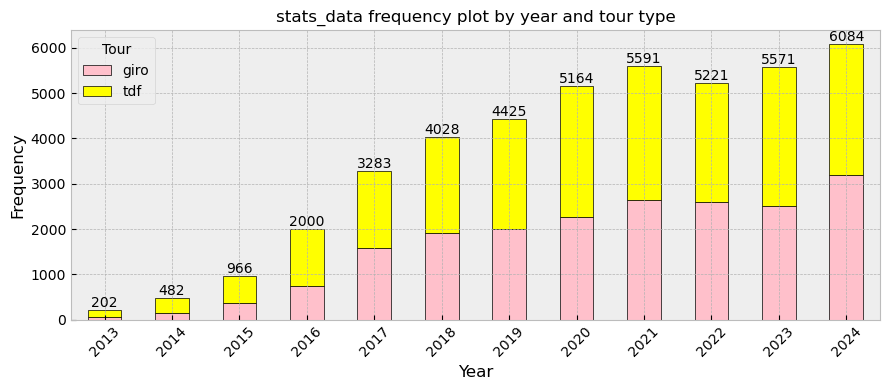

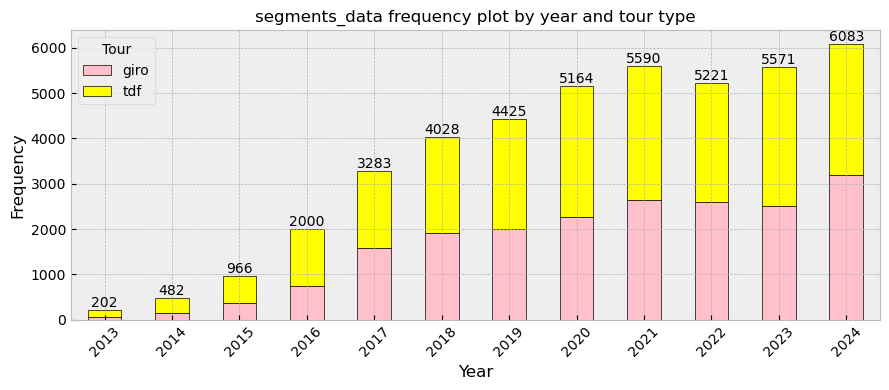

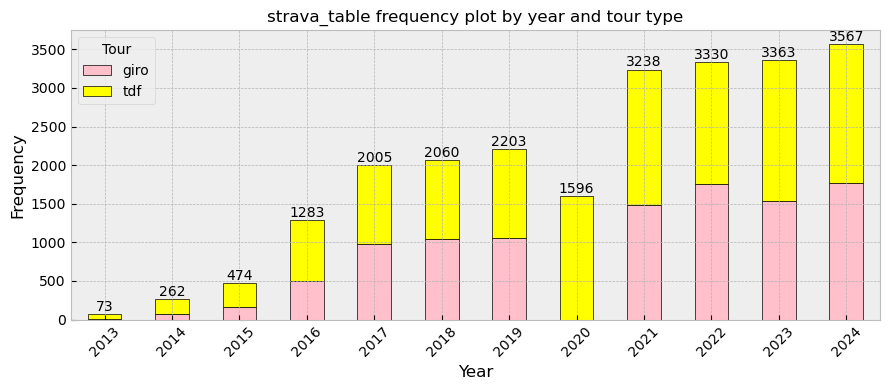

In [19]:
get_pandas_summary_of_starava_data(db_path, "stats_data")
get_pandas_summary_of_starava_data(db_path, "segments_data")
get_pandas_summary_of_starava_data(db_path, "strava_table")

In [25]:
def get_athlets_summary_for_specific_tour_year(db_path, table_name, tour_name, year):
    conn = sqlite3.connect(db_path)
    df = pd.read_sql(f"""SELECT * FROM "{table_name}" """, conn)  
    conn.close()
    #
    # Create a {tour:color} dictionary/map 
    tour_colors = {'tdf': 'yellow','giro': 'pink', 'vuelta': 'red'}
    #
    # Filter data for the selected year and tour
    filtered_df = df[(df['year'] == year) & (df['tour'] == tour_name)]
    # Count the frequency of each unique athlete_id then sort that by index
    id_counts = filtered_df['athlete_id'].value_counts().sort_index()
    #
    # Sort the entire DataFrame first and then selects the top m rows.
    m = 100
    top_m_id_counts = id_counts.sort_values(ascending=False).head(m)
    #
    #-----------------------------------#
    fig, ax2 = plt.subplots(figsize=(15, 4))
    #
    top_m_id_counts.plot(kind='bar', color=tour_colors[tour_name] , ax=ax2, ec='k', lw=0.5)
    # 
    for idx, id_num in enumerate(top_m_id_counts.index):
        total_count = top_m_id_counts.loc[id_num].sum()
        ax2.text(idx, total_count + 0.5, str(total_count), ha='center', va='bottom', fontsize=8, color='black')
    #
    ax2.set_title(f"{table_name} frequency of top " + str(m) + f" uploaders for {year}-{tour_name}")
    ax2.set_xlabel('athlete_ID')
    ax2.set_ylabel('Frequency')
    ax2.grid(axis='y', linestyle='--', alpha=0.7)
    fig.tight_layout()
    plt.savefig("Plots/"+ table_name + "_"+ "frequency_by_athlet_id_for_" + str(year) + "_" + tour_name +".png", bbox_inches='tight')
    plt.show()
    #-----------------------------------#
    return None

Top m uploaders of giro

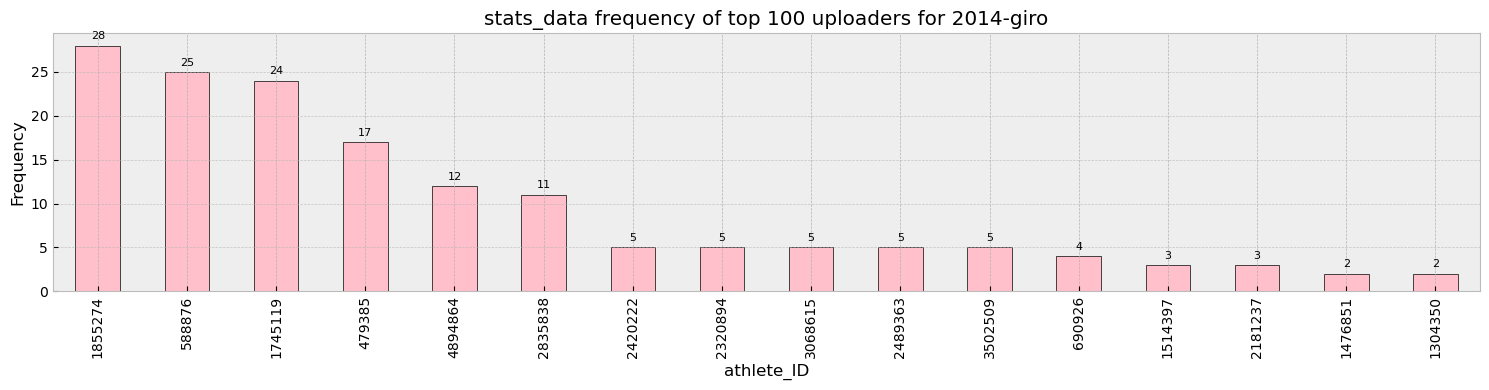

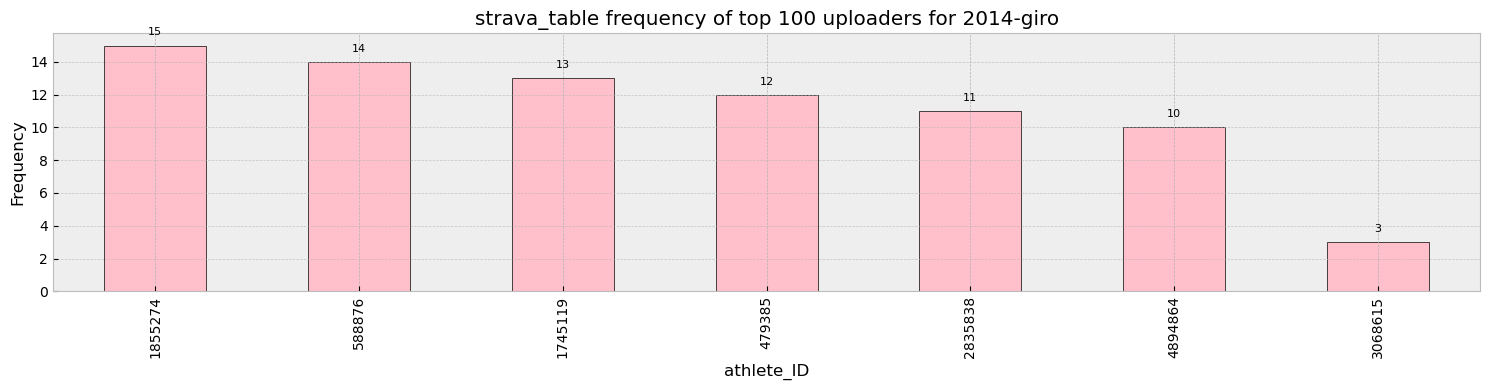

In [21]:
year = 2014 #pick year between 2013 & 2024
get_athlets_summary_for_specific_tour_year(db_path,'stats_data','giro', year)
# get_athlets_summary_for_specific_tour_year(db_path,'segments_data','giro', year)
get_athlets_summary_for_specific_tour_year(db_path,'strava_table','giro', year)

The <code>strava_table</code> is made by filtering the <code>stats_data</code> and <code>segments_data</code> tables. Next, for the top m uploaders in <code>strava_table</code>, we figure out where the (athlete_ID, count) appears in the <code>strava_table</code>

In [22]:
def summarize_top_strava_uploaders(db_path, table_name, tour_name, year):
    conn = sqlite3.connect(db_path)
    strava_df = pd.read_sql(f"""SELECT * FROM strava_table """, conn)  
    stat_or_segment_df = pd.read_sql(f"""SELECT * FROM "{table_name}" """, conn)  
    conn.close()
    #
    # Filter all for the selected year and tour by count into a DataFrame
    filtered_strava_df = strava_df[(strava_df['year'] == year) & (strava_df['tour'] == tour_name)]
    filtered_stat_df = stat_or_segment_df[(stat_or_segment_df['year'] == year) & (stat_or_segment_df['tour'] == tour_name)]
    #
    # Count the frequency of each unique athlete_id then sort that by index
    strava_id_counts = filtered_strava_df['athlete_id'].value_counts().sort_index()
    stat_id_counts = filtered_stat_df['athlete_id'].value_counts().sort_index()
    #
    sorted_strava_id = strava_id_counts.sort_values(ascending=False)
    sorted_stat_id = stat_id_counts.sort_values(ascending=False)
    #
    # since using sort_values() changes DataFrame to Series change it back 
    sorted_strava_id_df = sorted_strava_id.to_frame()
    sorted_stat_id_df = sorted_stat_id.to_frame()
    #
    # now use itertuples() to create a list of (athlete_ID, count) tuple
    sorted_strava_list = list(sorted_strava_id_df.itertuples(index=True, name=None))
    sorted_stat_list = list(sorted_stat_id_df.itertuples(index=True, name=None))
    #
    # print(sorted_strava_list)
    # print(sorted_stat_list)
    # #
    # Create a dictionary from list sorted_stat_list for quick lookup
    sorted_stat_dict = {id_val: (idx, count) for idx, (id_val, count) in enumerate(sorted_stat_list)}
    #
    # Create strava_list with the corresponding index & count from stat_list
    strava_stat_list = []  
    for id_val, strava_count in sorted_strava_list:
        index_in_stat = sorted_stat_dict[id_val][0]  # Get the index of id_val in B
        stat_count = sorted_stat_dict[id_val][1]  
        strava_stat_list.append((id_val, strava_count, index_in_stat, stat_count)) 
    #
    print("(athlete_id, count_in_starva_table, index_in_stat, count_in_stat_table)")
    for item in strava_stat_list:
        print(item)
    #
    return None

In [23]:
year = 2023 #pick year between 2013 & 2024
# summarize_top_strava_uploaders(db_path,'stats_data','giro', year)
summarize_top_strava_uploaders(db_path,'segments_data','giro', year)

(athlete_id, count_in_starva_table, index_in_stat, count_in_stat_table)
(2192184, 21, 15, 29)
(1821678, 20, 30, 27)
(39169689, 20, 19, 29)
(254096, 19, 21, 28)
(831403, 19, 13, 29)
(1405137, 19, 54, 23)
(584854, 19, 57, 22)
(240775, 19, 61, 21)
(1850959, 19, 4, 33)
(2006007, 19, 43, 24)
(2566327, 19, 23, 28)
(3123001, 19, 41, 25)
(3423315, 19, 72, 19)
(2922866, 19, 10, 30)
(3194779, 19, 12, 30)
(3125765, 19, 60, 21)
(1832492, 19, 9, 32)
(1936233, 19, 32, 26)
(1993533, 19, 40, 25)
(6782552, 19, 3, 35)
(4548902, 19, 5, 32)
(5571896, 19, 16, 29)
(3488983, 19, 42, 24)
(722861, 19, 28, 27)
(4672076, 19, 18, 29)
(12607976, 19, 6, 32)
(30466500, 19, 62, 21)
(15508012, 19, 50, 23)
(37167909, 19, 34, 26)
(49597893, 19, 64, 21)
(77293819, 19, 25, 27)
(19161146, 19, 39, 25)
(13125039, 19, 0, 58)
(2413208, 18, 52, 23)
(2676267, 18, 68, 20)
(7310716, 18, 47, 24)
(12274527, 18, 70, 19)
(12772912, 18, 38, 25)
(5201565, 18, 7, 32)
(9545283, 18, 36, 26)
(4057312, 18, 11, 30)
(4084289, 18, 8, 32)
(37379

Top m uploaders of tdf

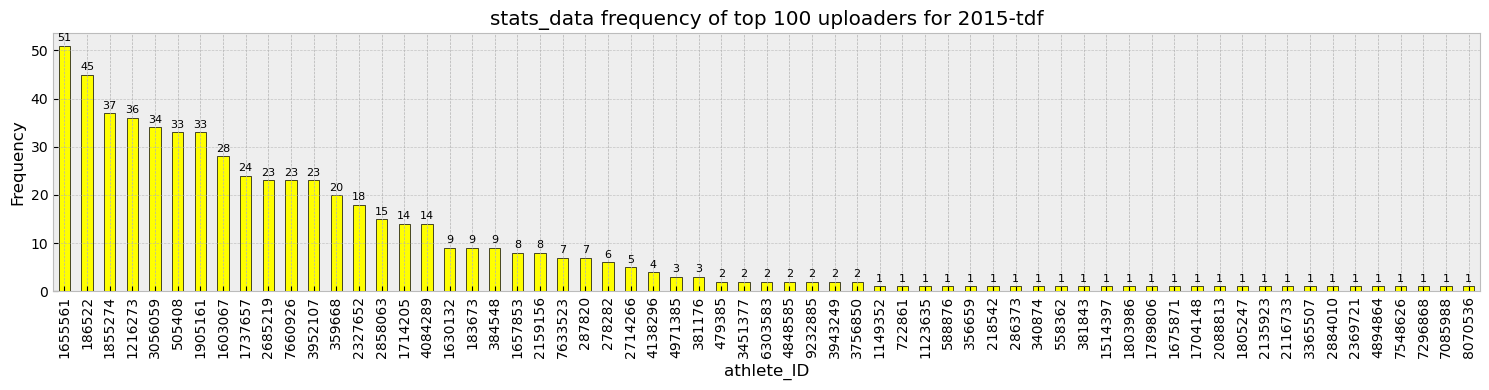

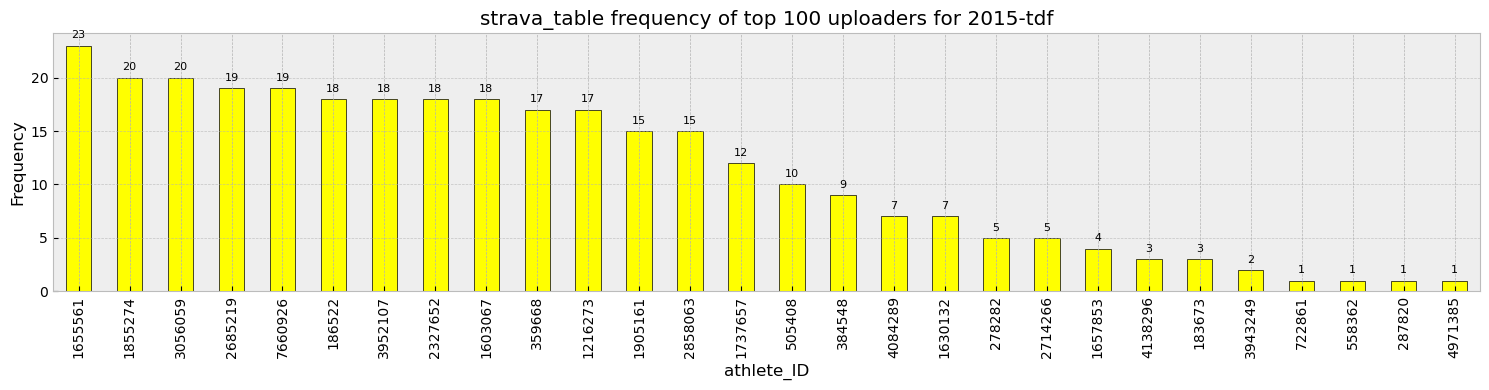

In [24]:
year = 2015 #pick year between 2013 & 2024
get_athlets_summary_for_specific_tour_year(db_path,'stats_data','tdf', year)
# get_athlets_summary_for_specific_tour_year(db_path,'segments_data','tdf', year)
get_athlets_summary_for_specific_tour_year(db_path,'strava_table','tdf', year)